# 03_01 — Specialist Ensemble Training

Train one specialist model per ToxiGen group and configure the ensemble voting weights.

**Design**
- Each specialist is fine-tuned with plain cross-entropy on its group's data only (no density weighting during training).
- Density weights are used exclusively at voting time.
- The K value and embedding space (raw / PCA) for the ensemble weights should be chosen based on the best general model configuration found in **notebook 04, section 3**.

**Sections**
1. Configuration
2. Train all specialists
3. Specialist metrics summary
4. Configure ensemble weights (pick K + space)

In [4]:
import sys, os
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.training import TrainingConfig
from src.training.specialist import train_all_specialists, TOXIGEN_GROUPS
from src.evaluation.ensemble import compute_group_weights, normalise_weights

sns.set_theme(style='whitegrid')

c:\Users\Alexandre\miniconda3\envs\faiss2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

In [5]:
CONFIG_PATH = 'configs/datasets.yaml'
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

EMBEDDINGS_ROOT   = cfg['embedding']['output_root']
PREPROCESSED_ROOT = cfg['preprocessing']['output_root']
TRAINING_ROOT     = cfg['training']['output_root']
MODEL_NAME        = cfg['embedding']['models'][0]
MODEL_SLUG        = MODEL_NAME.replace('/', '_')
K_VALUES          = cfg['embedding']['k_values']

train_cfg = cfg['training']

base_config = TrainingConfig(
    model_id      = train_cfg['models'][0],
    batch_size    = train_cfg['batch_size'],
    learning_rate = train_cfg['learning_rate'],
    num_epochs    = train_cfg['epochs'],
    max_length    = train_cfg['max_length'],
    random_state  = train_cfg['random_state'],
    output_root   = train_cfg['output_root'],
    density_column= None,   # specialists use plain CE
)

TOXIGEN_DENSITIES_CSV = os.path.join(EMBEDDINGS_ROOT, 'toxigen', MODEL_SLUG, 'densities.csv')

print('Model         :', base_config.model_id)
print('Epochs        :', base_config.num_epochs)
print('Groups        :', TOXIGEN_GROUPS)
print('Densities CSV :', TOXIGEN_DENSITIES_CSV)

Model         : answerdotai/ModernBERT-base
Epochs        : 3
Groups        : ['asian', 'black', 'chinese', 'jewish', 'latino', 'lgbtq', 'mental_dis', 'mexican', 'middle_east', 'muslim', 'native_american', 'physical_dis', 'women']
Densities CSV : outputs/2_embeddings\toxigen\sentence-transformers_all-mpnet-base-v2\densities.csv


## 2. Train All Specialists

One model per ToxiGen group, plain cross-entropy loss.  
Set `RUN_TRAINING = True` the first time. Subsequent runs load cached `metrics.json`.

In [4]:
RUN_TRAINING = True  # set True to train (slow)

if RUN_TRAINING:
    all_metrics = train_all_specialists(
        density_csv  = TOXIGEN_DENSITIES_CSV,
        config       = base_config,
        groups       = TOXIGEN_GROUPS,
        skip_existing= True,
    )
else:
    # Load cached metrics
    all_metrics = {}
    for group in TOXIGEN_GROUPS:
        path = os.path.join(
            TRAINING_ROOT, base_config.model_slug(),
            f'{group}__specialist', 'metrics.json'
        )
        if os.path.exists(path):
            with open(path) as f:
                all_metrics[group] = json.load(f)
        else:
            print(f'[MISSING] {group} — run with RUN_TRAINING=True')

print(f'Loaded metrics for {len(all_metrics)} specialists')

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 11253.43it/s]
[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Step,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,Precision,Recall,F1,Auc Roc
2000,0.133058,0.270548,0.918029,0.893912,0.868807,0.838053,0.853153,0.972127
2985,0.017621,0.485160,0.919034,0.891946,0.878987,0.829204,0.853370,0.971350


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.73s/it]


Training Loss,Validation Loss,Step,Accuracy,Balanced Accuracy,Precision,Recall,F1,Auc Roc
0.017621,0.270548,2985,0.918029,0.893912,0.868807,0.838053,0.853153,0.972127


Loading weights: 100%|██████████| 136/136 [00:00<00:00, 10284.98it/s]
[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


...

Step,Training Loss,Validation Loss,Accuracy,Balanced Accuracy,Precision,Recall,F1,Auc Roc
2000,0.047499,0.333041,0.920052,0.867821,0.830667,0.777778,0.803353,0.965214
2862,0.040226,0.468656,0.914286,0.864629,0.806202,0.779026,0.792381,0.963071


Writing model shards: 100%|██████████| 1/1 [00:05<00:00,  5.92s/it]


Training Loss,Validation Loss,Step,Accuracy,Balanced Accuracy,Precision,Recall,F1,Auc Roc
0.040226,0.333041,2862,0.920052,0.867821,0.830667,0.777778,0.803353,0.965214


Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.50s/it]


Loaded metrics for 13 specialists


## 3. Specialist Metrics Summary

In [5]:
if all_metrics:
    rows = [
        {
            'group'            : g,
            'f1'               : m.get('f1', float('nan')),
            'balanced_accuracy': m.get('balanced_accuracy', float('nan')),
            'accuracy'         : m.get('accuracy', float('nan')),
            'auc_roc'          : m.get('auc_roc', float('nan')),
        }
        for g, m in all_metrics.items()
    ]
    summary = pd.DataFrame(rows).sort_values('f1', ascending=False).set_index('group')
    display(
        summary.style
        .format('{:.4f}')
        .background_gradient(subset=['f1'], cmap='YlGn')
    )
else:
    print('No metrics yet — train first.')

,f1,balanced_accuracy,accuracy,auc_roc
group,,,,
mexican,0.8730,0.9105,0.9283,0.9777
middle_east,0.8569,0.8879,0.9180,0.9723
jewish,0.8564,0.8918,0.9135,0.9678
asian,0.8532,0.8939,0.9180,0.9721
muslim,0.8443,0.8888,0.9189,0.9675
black,0.8417,0.8796,0.9117,0.9717
mental_dis,0.8363,0.9005,0.9319,0.9742
latino,0.8360,0.8808,0.8986,0.9527
native_american,0.8333,0.8886,0.9256,0.9686


C:\Users\Alexandre\AppData\Local\Temp\ipykernel_9072\3342841773.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups_sorted, rotation=45, ha='right')


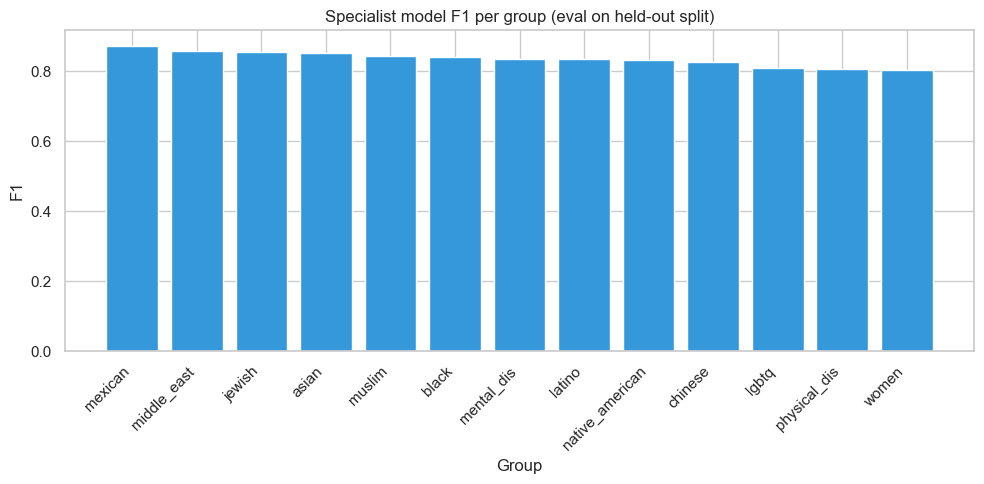

In [6]:
if all_metrics:
    fig, ax = plt.subplots(figsize=(10, 5))
    groups_sorted = summary.index.tolist()
    ax.bar(groups_sorted, summary.loc[groups_sorted, 'f1'], color='#3498db')
    ax.set_xlabel('Group')
    ax.set_ylabel('F1')
    ax.set_title('Specialist model F1 per group (eval on held-out split)')
    ax.set_xticklabels(groups_sorted, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. Configure Ensemble Weights

Choose `K` and `SPACE` based on the best general model configuration from **notebook 04**.  
The table below shows the pre-computed group weights for your chosen configuration.

In [6]:
# --- Set these based on the best general model in notebook 04 ---
K     = 100    # best K value from general model evaluation
SPACE = 'pca'  # 'raw' or 'pca'

In [7]:
# --- Configure Ensemble Normalisation ---
# Methods: 
#   "softmax" (Recommended for log-densities, uses temperature T)
#   "linear"  (Shifted linear scaling with a non-zero floor)
NORM_METHOD = "softmax" 
NORM_TEMP   = 5.0      

raw_weights = compute_group_weights(TOXIGEN_DENSITIES_CSV, k=K, space=SPACE)

# Compute both for comparison
weights_softmax = normalise_weights(raw_weights, method="softmax", temperature=NORM_TEMP)
weights_linear  = normalise_weights(raw_weights, method="linear")

# Select the method to use for the rest of the notebook
norm_weights = weights_softmax if NORM_METHOD == "softmax" else weights_linear

weights_df = (
    pd.DataFrame([
        {
            'group': g, 
            'raw_log_density': raw_weights[g], 
            'softmax_weight': weights_softmax[g],
            'linear_weight': weights_linear[g]
        }
        for g in sorted(raw_weights)
    ])
    .set_index('group')
    .sort_values('softmax_weight', ascending=False)
)

print(f"Normalisation Method: {NORM_METHOD} (T={NORM_TEMP if NORM_METHOD == 'softmax' else 'N/A'})")
display(
    weights_df.style.format('{:.4f}')
    .background_gradient(subset=['softmax_weight'], cmap='YlGn')
    .background_gradient(subset=['linear_weight'], cmap='YlOrRd')
)


Normalisation Method: softmax (T=5.0)


,raw_log_density,softmax_weight,linear_weight
group,,,
jewish,191.9560,0.2707,0.1412
middle_east,189.1054,0.1531,0.1176
muslim,186.8445,0.0974,0.0989
chinese,185.2544,0.0709,0.0857
women,185.1546,0.0695,0.0849
latino,184.9004,0.0660,0.0828
mexican,184.6245,0.0625,0.0805
native_american,184.0422,0.0556,0.0757
lgbtq,183.4429,0.0493,0.0708
